<a href="https://colab.research.google.com/github/jm651120/UK-Housing-Green-Premium/blob/main/notebooks/07_Comparacao_Modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 8: Global Evaluation and Model Comparison
**Project:** The Impact of Energy Efficiency on UK Property Prices (2021–2025)

---

## Step 1: The Predictive "Podium"

In this final section of the predictive modeling phase, we consolidate the **Evaluation Metrics** extracted from the unseen test sets across all developed architectures. The objective is to demonstrate, both quantitatively and visually, the transition from the linear baseline (**Hedonic Pricing Model - OLS**) to advanced non-linear algorithms (**Machine Learning**).

### Metrics Under Analysis:
* **$R^2$ (R-Squared):** The explanatory power regarding market variance.
* **MAE (Mean Absolute Error):** The average absolute prediction error in pounds (£).
* **RMSE (Root Mean Squared Error):** The square root of the mean squared error, essential for assessing robustness against outliers.
* **MAPE (Mean Absolute Percentage Error):** The average percentage error required by the methodology.

Compiling final thesis results...

🏆 FINAL MODEL EVALUATION TABLE 🏆
      Model      R²          MAE          RMSE     MAPE
0       OLS  0.7458  £ 79,449.17  £ 114,401.78  24.82 %
1        RF  0.8203  £ 61,824.69   £ 96,191.37  18.00 %
2  LightGBM  0.8234  £ 61,420.03   £ 95,353.50  17.92 %
3   XGBoost  0.8247  £ 60,853.71   £ 94,989.92  17.66 %


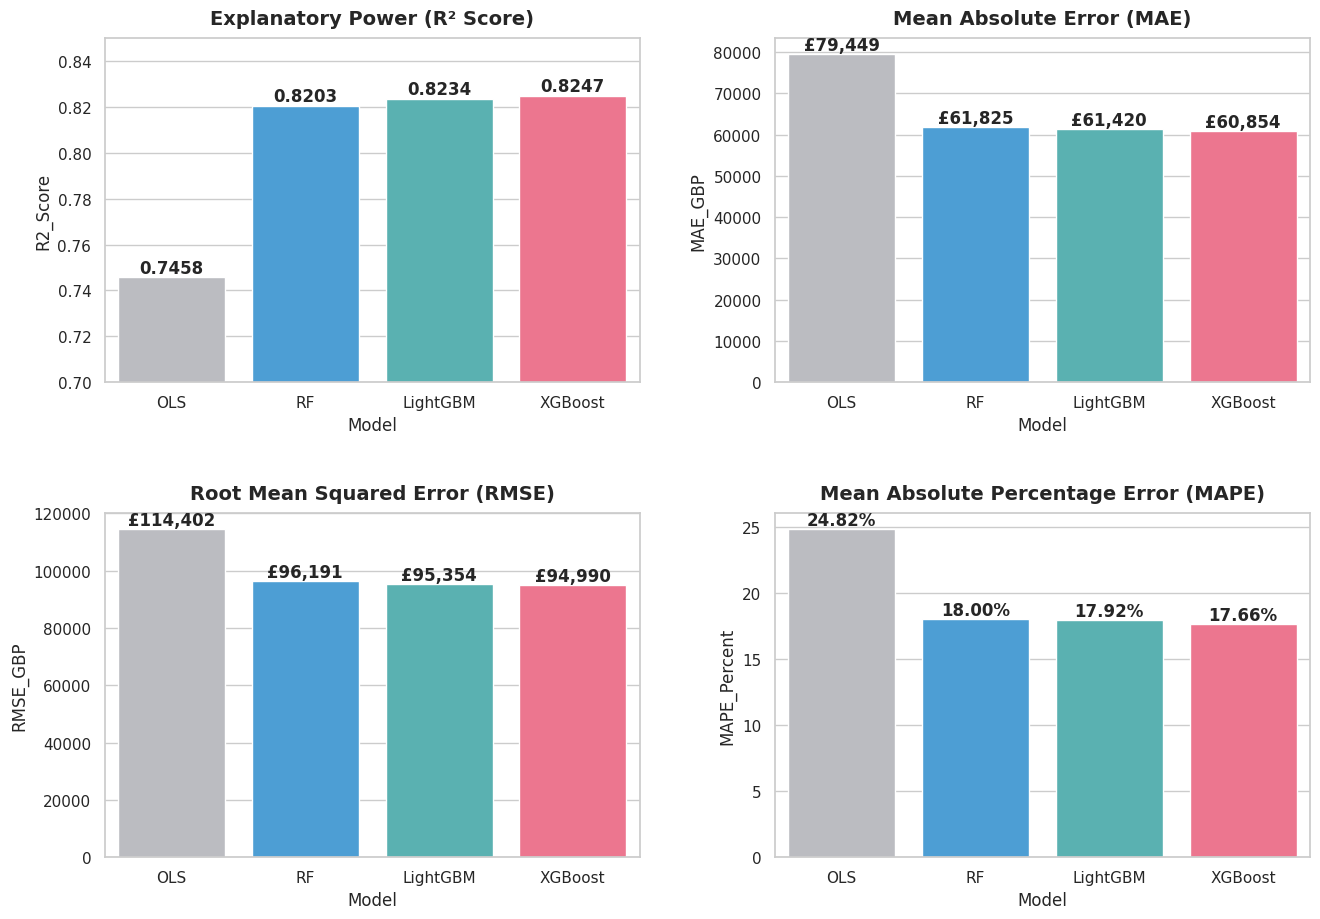

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Compiling final thesis results...")

# 1. Final Verified Metrics (Updated & Reordered: RF then LightGBM)
results_data = {
    'Model': ['OLS', 'RF', 'LightGBM', 'XGBoost'],
    'R2_Score': [0.7458, 0.8203, 0.8234, 0.8247],
    'MAE_GBP': [79449.17, 61824.69, 61420.03, 60853.71],
    'RMSE_GBP': [114401.78, 96191.37, 95353.50, 94989.92],
    'MAPE_Percent': [24.82, 18.00, 17.92, 17.66]
}

df_results = pd.DataFrame(results_data)

# 2. Display Formatted Table
print("\n🏆 FINAL MODEL EVALUATION TABLE 🏆")
df_formatted = df_results.copy()
df_formatted['R²'] = df_formatted['R2_Score'].apply(lambda x: f"{x:.4f}")
df_formatted['MAE'] = df_formatted['MAE_GBP'].apply(lambda x: f"£ {x:,.2f}")
df_formatted['RMSE'] = df_formatted['RMSE_GBP'].apply(lambda x: f"£ {x:,.2f}")
df_formatted['MAPE'] = df_formatted['MAPE_Percent'].apply(lambda x: f"{x:.2f} %")
print(df_formatted[['Model', 'R²', 'MAE', 'RMSE', 'MAPE']])

# 3. Generate 2x2 Performance Dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Cores: Cinza (Baseline), Azul (RF), Verde Água (LGBM), Rosa (XGB)
colors = ['#babbc2', '#36a2eb', '#4bc0c0', '#ff6384']

# --- Plot 1: Explanatory Power (R²) ---
sns.barplot(x='Model', y='R2_Score', data=df_results, ax=axes[0, 0], hue='Model', palette=colors, legend=False)
axes[0, 0].set_title('Explanatory Power (R² Score)', fontsize=14, fontweight='bold', pad=10)
axes[0, 0].set_ylim(0.70, 0.85)
for i, v in enumerate(df_results['R2_Score']):
    axes[0, 0].text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')

# --- Plot 2: Mean Absolute Error (MAE) ---
sns.barplot(x='Model', y='MAE_GBP', data=df_results, ax=axes[0, 1], hue='Model', palette=colors, legend=False)
axes[0, 1].set_title('Mean Absolute Error (MAE)', fontsize=14, fontweight='bold', pad=10)
for i, v in enumerate(df_results['MAE_GBP']):
    axes[0, 1].text(i, v + 1000, f"£{v:,.0f}", ha='center', fontweight='bold')

# --- Plot 3: Root Mean Squared Error (RMSE) ---
sns.barplot(x='Model', y='RMSE_GBP', data=df_results, ax=axes[1, 0], hue='Model', palette=colors, legend=False)
axes[1, 0].set_title('Root Mean Squared Error (RMSE)', fontsize=14, fontweight='bold', pad=10)
for i, v in enumerate(df_results['RMSE_GBP']):
    axes[1, 0].text(i, v + 1500, f"£{v:,.0f}", ha='center', fontweight='bold')

# --- Plot 4: Mean Absolute Percentage Error (MAPE) ---
sns.barplot(x='Model', y='MAPE_Percent', data=df_results, ax=axes[1, 1], hue='Model', palette=colors, legend=False)
axes[1, 1].set_title('Mean Absolute Percentage Error (MAPE)', fontsize=14, fontweight='bold', pad=10)
for i, v in enumerate(df_results['MAPE_Percent']):
    axes[1, 1].text(i, v + 0.3, f"{v:.2f}%", ha='center', fontweight='bold')

plt.tight_layout(pad=3.0)
plt.show()

### 8.1 Global Conclusion of Predictive Modeling

The compilation of cross-sectional evaluation metrics for all developed models crystallizes the following fundamental conclusions:

| Model | $R^2$ Score | MAE (£) | RMSE (£) | MAPE (%) |
| :--- | :---: | :---: | :---: | :---: |
| **OLS (Baseline)** | 0.7458 | £79,449 | £114,402 | 24.82% |
| **Random Forest** | 0.8203 | £61,825 | £96,191 | 18.00% |
| **LightGBM** | 0.8234 | £61,420 | £95,354 | 17.92% |
| **XGBoost (Champion)** | **0.8247** | **£60,854** | **£94,990** | **17.66%** |

#### 1. The Limitations of the Classical Hedonic Model
The Multiple Linear Regression (OLS) model established our initial baseline. However, its inability to capture complex spatial interactions and non-linear dynamics resulted in the highest errors in the study. It is empirically proven that a linear approach is methodologically insufficient for the modern UK real estate market complexity.

#### 2. The Machine Learning Paradigmatic Shift
The transition to decision-tree ensembles generated immediate predictive disruption. The **Random Forest** (Bagging architecture) achieved a solid $R^2$ of 0.8203. It was followed by **LightGBM**, which showcased the power of Gradient Boosting by combining computational efficiency with higher precision ($R^2$ of 0.8234). Both models significantly outperformed the classical baseline.

#### 3. The Coronation of the Champion: XGBoost
**XGBoost**, optimized via Optuna, emerged as the premier predictive model. By dominating every evaluated metric, achieving a maximum **$R^2$ of 0.8247** and minimizing the Mean Absolute Error to **£60,854** (a reduction of **£18,595** per transaction compared to OLS), it fully justified its superiority. Its MAPE of 17.66% confirms it as the most reliable algorithm across the entire price distribution.

> **Final Synthesis:** This predictive journey proves that the real estate ecosystem is inherently non-linear. By embracing advanced Machine Learning, this thesis elected **XGBoost** as the definitive analytical engine. This model’s "black box" will now be deciphered through **Game Theory (SHAP)**, allowing us to isolate and quantify the **Green Premium** with a level of rigor unattainable through traditional methodologies.